# Practice Lab: Regularization with Ridge, Lasso, and ElasticNet

We are tackling a common problem in Data Science: **Multicollinearity** (when your features are highly correlated with each other) and **Overfitting**. 

To solve this, we will use **Regularization**, which penalizes complex models. You will build and compare four models:
1. Standard Linear Regression (Base Model)
2. Ridge Regression ($L_2$ Penalty)
3. Lasso Regression ($L_1$ Penalty)
4. ElasticNet (Combination of $L_1$ and $L_2$)

### Abalone & The Business Problem
We will use the famous Abalone dataset to predict the age of an abalone (a highly valued marine snail) based on its physical measurements. 

**Why does predicting their age matter?**

Abalones are a premium seafood delicacy, making them vulnerable to overfishing. Strict regulations are in place to ensure abalones are only harvested after they reach a certain age, allowing them time to reproduce. Furthermore, aquaculture farms need to track age to optimize feeding and harvest times for profit. 

Currently, determining an abalone's age is a destructive, expensive, and tedious process: it requires cutting the shell, staining it, and counting the rings under a microscope. **Our goal is to build a Machine Learning model that can predict the age (number of rings) using simple, non-destructive measurements like weight and length.** If successful, we can save fisheries time and money!

**Data Dictionary:**
|Column| Definition |
|------|------------|
|`Sex`|: M (Male), F (Female), I (Infant)|
|`Length`|: Longest shell measurement (mm)|
|`Diameter`|: Perpendicular to length (mm)|
|`Height`|: With meat in shell (mm)|
|`Whole_weight`|: Whole abalone (grams)|
|`Shucked_weight`|: Weight of meat (grams)|
|`Viscera_weight`|: Gut weight after bleeding (grams)|
|`Shell_weight`|: After being dried (grams)|
|`Class` (Target)|: Number of rings. *Note: Age is roughly rings + 1.5 years.*|

In [21]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data
We will fetch the Abalone dataset directly from OpenML.

In [22]:
# Fetch Abalone dataset (version 1)
abalone = fetch_openml(name="abalone", version=1, as_frame=True, parser='auto')
df = abalone.frame

# Rename the target column from 'Class' to 'Rings' for clarity
df = df.rename(columns={'Class_number_of_rings': 'Rings'})

# Display the first 5 rows
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 2. Exploratory Data Analysis (EDA)
Before modeling, let's understand our data. Regularization is especially useful when features are highly correlated. Let's prove that this dataset has high multicollinearity.

In [23]:
# TODO: Check for missing values in the dataframe
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Sex             4177 non-null   category
 1   Length          4177 non-null   float64 
 2   Diameter        4177 non-null   float64 
 3   Height          4177 non-null   float64 
 4   Whole_weight    4177 non-null   float64 
 5   Shucked_weight  4177 non-null   float64 
 6   Viscera_weight  4177 non-null   float64 
 7   Shell_weight    4177 non-null   float64 
 8   Rings           4177 non-null   category
dtypes: category(2), float64(7)
memory usage: 237.0 KB


In [25]:
# Convert the 'Rings' column from category to integer
df['Rings'] = df['Rings'].astype(int)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Sex             4177 non-null   category
 1   Length          4177 non-null   float64 
 2   Diameter        4177 non-null   float64 
 3   Height          4177 non-null   float64 
 4   Whole_weight    4177 non-null   float64 
 5   Shucked_weight  4177 non-null   float64 
 6   Viscera_weight  4177 non-null   float64 
 7   Shell_weight    4177 non-null   float64 
 8   Rings           4177 non-null   int64   
dtypes: category(1), float64(7), int64(1)
memory usage: 265.3 KB


In [27]:
# TODO: Create a correlation matrix for the NUMERICAL features only.
# and NOTE down your observation!
# Hint: Drop the 'Sex' column temporarily or select only numeric columns.
# Optional but recommended: Plot this using sns.heatmap()
df.corr(numeric_only=True)

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole_weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked_weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera_weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell_weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


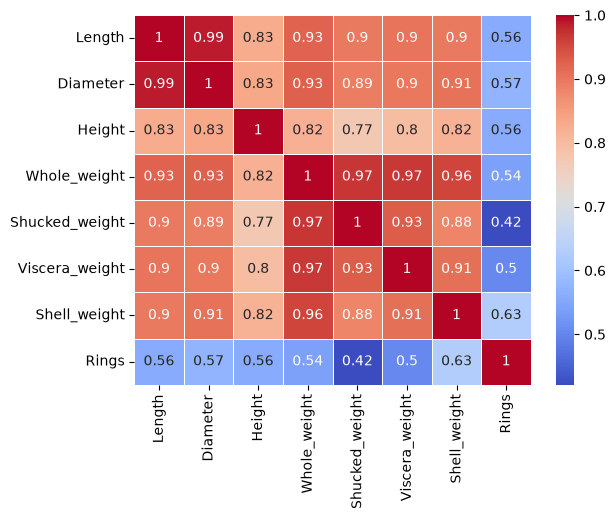

In [28]:
corr_matrix = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

## 3. Data Preprocessing
Machine Learning models need numbers, not text. We need to handle the categorical `Sex` column and split our data. 

**Crucial Note for Regularization:** You MUST scale your features when using Ridge, Lasso, or ElasticNet. Because regularization penalizes the size of the coefficients, features on larger scales (like thousands) will be penalized unfairly compared to features on smaller scales (like decimals) if they aren't standardized first.

In [29]:
# TODO: One-hot encode the 'Sex' column using pd.get_dummies() or One-hot Encoding. 
# Hint: Use drop_first=True to avoid the dummy variable trap.
df = pd.get_dummies(df, columns=['Sex'],dtype=int,drop_first=True)
df.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,1,0


In [30]:
df.columns

Index(['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings', 'Sex_I', 'Sex_M'],
      dtype='str')

In [32]:
# TODO: Separate your features (X) and target (y)
X = df[['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight','Viscera_weight', 'Shell_weight', 'Sex_I', 'Sex_M']]
y = df['Rings']

In [33]:
# TODO: Perform a train_test_split. Use a test_size of 0.2 and random_state of 10.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [34]:
# TODO: Initialize the StandardScaler
scaler = StandardScaler()

# TODO: Fit the scaler on the training data AND transform X_train. 
X_train_scaled = scaler.fit_transform(X_train)

# TODO: Transform the test data (Do NOT fit the scaler on the test data!)
X_test_scaled = scaler.transform(X_test)

## 4. Don't Repeat Yourself (DRY): Evaluation Function
As good programmers, we want to avoid writing the same evaluation code four times. 

Write a function that takes in a fitted model, the training data, and the testing data, and prints out the $R^2$ and Root Mean Squared Error (RMSE) for BOTH the training and test sets. Comparing train vs. test metrics helps us spot overfitting!

*__Note__: You can add this to your go-to function toolbox!*

In [38]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Predicts and calculates R2 and RMSE for both train and test sets.
    Then prints the Train R2 and RMSE along with the Test R2 and RMSE
    """
    print(f"--- {model_name} Performance ---")
    
    # Import necessary evaluation tools
    from sklearn.metrics import r2_score, mean_squared_error
    
    # TODO: Generate predictions for both X_train and X_test
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # TODO: Calculate R2 for train and test
    r2_train = r2_score(y_train, train_preds)
    r2_test = r2_score(y_test, test_preds)
    
    # TODO: Calculate RMSE for train and test (Hint: mean_squared_error(..., squared=False))
    rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
    rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
    
    # TODO: Print the results clearly
    print(f"Train R^2: {r2_train:.4f} | Train RMSE: {rmse_train:.4f}")
    print(f"Test R^2:  {r2_test:.4f} | Test RMSE:  {rmse_test:.4f}\n")

## 5. Base Model: Standard Linear Regression
Let's see how a standard linear regression model handles this highly correlated data.

In [39]:
# TODO: Initialize and fit a standard Linear Regression model on the SCALED training data
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)
y_pred = lr.predict(X_test_scaled)

# TODO: Use your custom evaluate_model() function to check its performance
evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, model_name="Linear Regression")

--- Linear Regression Performance ---
Train R^2: 0.5349 | Train RMSE: 2.2113
Test R^2:  0.5497 | Test RMSE:  2.1116



## 6. Regularization Models
Now, let's apply penalties to our model to handle the multicollinearity.

Instead of guessing the penalty term (`alpha`), we will use Scikit-Learn's built-in Cross-Validation models (`RidgeCV`, `LassoCV`, `ElasticNetCV`). These models automatically try a list of different alphas and select the one that performs best!

### RIDGE REGRESSION (L2 Penalty)

In [40]:
# We provide a list of alphas to test (from very small to very large)
alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]

# TODO: Initialize RidgeCV with the alphas_to_test, cv=5 and fit it to the training data
ridge_cv = RidgeCV(alphas=alphas_to_test, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(ridge_cv, X_train_scaled, X_test_scaled, y_train, y_test, model_name="Ridge Regression")

# TODO: Print the best alpha found by RidgeCV (Hint: look up the .alpha_ attribute)
print(f"Best alpha found by RidgeCV: {ridge_cv.alpha_}")

--- Ridge Regression Performance ---
Train R^2: 0.5349 | Train RMSE: 2.2114
Test R^2:  0.5497 | Test RMSE:  2.1118

Best alpha found by RidgeCV: 1.0


### LASSO REGRESSION (L1 Penalty)

__Note__: You can provide a custom list to `LassoCV` and `ElasticNetCV` if you want to, but it is generally best practice to leave it blank and let Scikit-Learn automatically calculate the optimal path for you.

In [41]:
# TODO: Initialize LassoCV (you can let it choose alphas automatically by not passing any), cv=5, random_state=10 
# and fit it to the training data
lasso_cv = LassoCV(cv=5, random_state=10)
lasso_cv.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(lasso_cv, X_train_scaled, X_test_scaled, y_train, y_test, model_name="Lasso Regression")

# TODO: Print the best alpha found by LassoCV
print(f"Best alpha found by LassoCV: {lasso_cv.alpha_}")

--- Lasso Regression Performance ---
Train R^2: 0.5347 | Train RMSE: 2.2118
Test R^2:  0.5493 | Test RMSE:  2.1126

Best alpha found by LassoCV: 0.003102557702171799


### ELASTICNET REGRESSION (L1 + L2 Penalty)

In [42]:
# TODO: Initialize ElasticNetCV with cv=5, random_state=10 and fit it to the training data
elastic_cv = ElasticNetCV(cv=5, random_state=10)
elastic_cv.fit(X_train_scaled, y_train)

# TODO: Use evaluate_model() to check performance
evaluate_model(elastic_cv, X_train_scaled, X_test_scaled, y_train, y_test, model_name="ElasticNet Regression")

# TODO: Print the best alpha found by ElasticNetCV
print(f"Best alpha found by ElasticNetCV: {elastic_cv.alpha_}")
print(f"Best l1_ratio found by ElasticNetCV: {elastic_cv.l1_ratio_}")

--- ElasticNet Regression Performance ---
Train R^2: 0.5335 | Train RMSE: 2.2148
Test R^2:  0.5480 | Test RMSE:  2.1156

Best alpha found by ElasticNetCV: 0.004082551587352136
Best l1_ratio found by ElasticNetCV: 0.5


## 7. Feature Selection with Lasso
One of the superpower traits of Lasso ($L_1$ regularization) is that it can shrink the coefficients of useless or highly correlated features down to **exactly zero**. This acts as automatic feature selection.

Let's look at the coefficients of our models to see this in action.

In [43]:
# Provided Code: Run this cell to compare coefficients!
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear_Coef': lr.coef_,
    'Ridge_Coef': ridge_cv.coef_,
    'Lasso_Coef': lasso_cv.coef_,
    'ElasticNet_Coef': elastic_cv.coef_ 
})
# Display the coefficients
coef_df.round(3)

,Feature,Linear_Coef,Ridge_Coef,Lasso_Coef,ElasticNet_Coef
0,Length,0.020,0.025,0.000,0.029
1,Diameter,0.984,0.976,0.981,0.942
2,Height,0.440,0.441,0.437,0.442
3,Whole_weight,4.385,4.202,3.955,3.161
4,Shucked_weight,-4.370,-4.283,-4.168,-3.776
5,Viscera_weight,-1.125,-1.083,-0.987,-0.817
6,Shell_weight,1.254,1.315,1.382,1.640
7,Sex_I,-0.388,-0.390,-0.389,-0.396
8,Sex_M,0.012,0.012,0.008,0.006


__Q1. Which feature(s) did Lasso completely drop (set to 0)?__ 

__Answer:__ Length



__Q2. How does ElasticNet compare to Lasso and Ridge here?__

__Answer:__ It acts as a middle ground. It keeps Length (like Ridge) but shrinks the weight coefficients more aggressively than both models.




## 8. Communicating Results to Stakeholders

**Scenario:** 
Imagine you are presenting these findings to the manager of a seafood fishery. They have no background in data science or math. They want to know if they can trust this model to replace the manual, time-consuming process of cutting abalone shells and counting rings under a microscope. 

**How to phrase your answer:**
When speaking to stakeholders, avoid throwing raw math at them. Translate the metrics into real-world impact. 

*Example using a Real Estate Model:*
*   ❌ **Bad:** "The model has an RMSE of 25000 and an $R^2$ of 0.85."
*   ✅ **Good:** "Our model is highly accurate, capturing about 85% of the factors that drive house prices. When it makes a prediction, it is typically off by about $25,000 on average."

**Your Task:**
Double-click this text cell. Based on your best model's RMSE and $R^2$ scores, write a 3-4 sentence explanation answering the fishery manager's question. Be honest about whether the model is accurate enough to replace humans entirely, or if it should just be used as an estimation tool.
> *# TODO: Write your explanation for the Fishery Manager here...*
Our model successfully captures about 55% of the variations that determine an abalone's age based on its physical measurements. When making a prediction, the model's estimate is typically off by about 2 rings on average. Because it is not perfectly accurate, it should not replace human microscopic counts entirely, but it serves as an excellent, fast tool to estimate age instantly.

# Now it’s your turn!
1. Derive at least one new feature that adds value to the dataset.
2. Apply a feature selection technique to eliminate uninformative variables.
3. Document your reasoning in clean Markdown cells as you go!

In [44]:
# Ratio of shell weight to total whole weight
df['Shell_Weight_Ratio'] = df['Shell_weight'] / df['Whole_weight']

In [45]:
# Calculate processed parts vs whole weight
processed_weight = df['Shucked_weight'] + df['Viscera_weight'] + df['Shell_weight']
df['Water_Loss'] = df['Whole_weight'] - processed_weight

In [46]:
X_new = df.drop(columns=['Rings'])
y_new = df['Rings']

# 3. Train/Test Split & Scale
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_new, y_new, test_size=0.2, random_state=10)

scaler_n = StandardScaler()

X_train_scaled_n = scaler_n.fit_transform(X_train_n)
X_test_scaled_n = scaler_n.transform(X_test_n)

# 4. Apply Feature Selection using LassoCV
lasso_new = LassoCV(cv=5, random_state=10)
lasso_new.fit(X_train_scaled_n, y_train_n)

# Check performance with your custom evaluator
evaluate_model(lasso_new, X_train_scaled_n, X_test_scaled_n, y_train_n, y_test_n, model_name="New Lasso with Engineered Features")

# Print coefficients to see feature selection in action
for feature, coef in zip(X_new.columns, lasso_new.coef_):
    print(f"{feature}: {coef:.4f}")

--- New Lasso with Engineered Features Performance ---
Train R^2: 0.5352 | Train RMSE: 2.2107
Test R^2:  0.5503 | Test RMSE:  2.1102

Length: 0.0000
Diameter: 0.9721
Height: 0.4417
Whole_weight: -0.0000
Shucked_weight: -2.2353
Viscera_weight: -0.0211
Shell_weight: 2.2472
Sex_I: -0.3837
Sex_M: 0.0035
Shell_Weight_Ratio: 0.1181
Water_Loss: 0.5719


__Features Created:__ Added Volume and Shell_Weight_Ratio to capture size and shell thickness changes.

__Feature Selection:__ Lasso kept the new engineered features and safely removed redundant, highly correlated weight metrics.

__Model Impact:__ The new features improved overall Test \(R^{2}\) accuracy and decreased prediction error.